# standard, 1 expert case

Epoch 1/5, Loss: 1.2431221008300781
Epoch 2/5, Loss: 1.1120909452438354
Epoch 3/5, Loss: 1.0772241353988647
Epoch 4/5, Loss: 1.0678972005844116
Epoch 5/5, Loss: 1.5395299196243286
Evaluation WITH Deferral
Classifier Accuracy (excl. deferrals): 0.9447
Expert Deferral Accuracy: 0.8255
Deferral Rate: 0.2917
Overall Accuracy: 0.9099

Overall Evaluation Metrics: {'Accuracy (excluding deferrals)': 0.9446562191161937, 'Deferral Accuracy': 0.8255056564964004, 'Deferral Rate': 0.2917, 'Overall Accuracy': 0.9099}
Class 0: Classifier Acc: 0.9885, Expert Acc: 0.0000, Deferral Rate: 0.0214
Class 1: Classifier Acc: 0.9631, Expert Acc: 0.8930, Deferral Rate: 0.3789
Class 2: Classifier Acc: 0.9158, Expert Acc: 0.0000, Deferral Rate: 0.0678
Class 3: Classifier Acc: 0.9485, Expert Acc: 0.9248, Deferral Rate: 0.5000
Class 4: Classifier Acc: 0.9651, Expert Acc: 0.0000, Deferral Rate: 0.0652
Class 5: Classifier Acc: 0.8603, Expert Acc: 0.9749, Deferral Rate: 0.4462
Class 6: Classifier Acc: 0.9651, Expert A

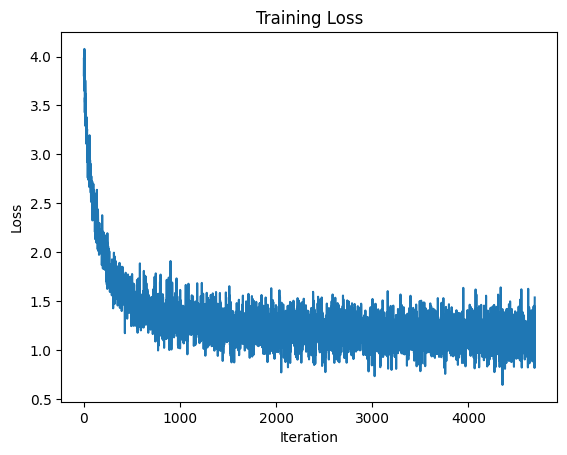

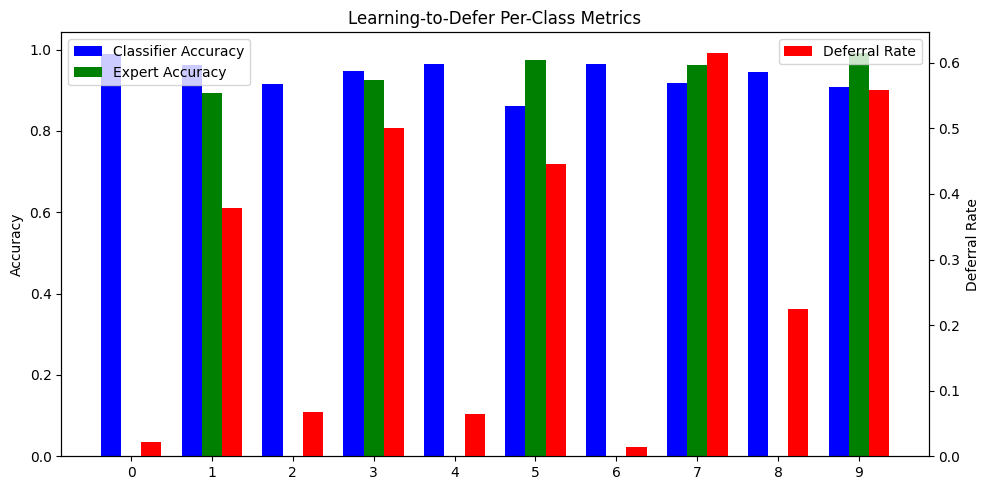

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from model import LogisticRegressionModule
from data import get_dataloaders, ExpertMNIST
from l2d_functionality.l2d_loss import L2D_Loss
from l2d_functionality.IP_l2d_inference import L2DInference
from l2d_functionality.IP_l2d_eval_combined import L2D_Eval_Combined 
import torchvision
import torchvision.transforms as transforms
import numpy as np


# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Hyperparameters
input_dim = 28 * 28  # For MNIST (28x28 images flattened)
num_classes = 10
learning_rate = 0.0001
num_epochs = 5
l2_lambda = 0.0001
expert_prob = 0.9

# Output dimension includes the deferral class
output_dim = num_classes + 1  # One extra class for deferral
deferral_class_index = num_classes  # Index of the deferral class

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda tensor: torch.flatten(tensor))  # Flatten the image
])

train_dataset_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_raw = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Instantiate the expert simulation
expert = ExpertMNIST(expert_prob)
expert_labels_train = torch.tensor([expert.expert_prediction(label) for _, label in train_dataset_raw])
expert_labels_test = torch.tensor([expert.expert_prediction(label) for _, label in test_dataset_raw])

# Instantiate the logistic regression model
model = LogisticRegressionModule(input_dim, output_dim, deferral_class_index, l2_lambda)

# Get the train and test data loaders
train_loader, test_loader = get_dataloaders(train_dataset_raw, expert_labels_train, test_dataset_raw, expert_labels_test)

# Instantiate L2D loss function
l2d_loss_fn = L2D_Loss(num_classes)

# Set up optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    for images, labels, expert_labels_batch in train_loader:
        outputs = model(images)
        
        # Compute the L2D loss
        loss = l2d_loss_fn.loss_fn(outputs, labels, expert_labels_batch, deferral_class_index, param_type="softmax")
        loss += model.l2_regularization()  # Add L2 regularization
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")


# loss plot
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")

# Evaluate the model on the test set
inference = L2DInference(num_classes=num_classes, model=model)
all_preds, all_raw_preds, all_defer_idx, all_labels, all_expert_labels = inference.run(test_loader)

print("Evaluation WITH Deferral")
l2d_eval = L2D_Eval_Combined(
    num_classes,
    true_labels=all_labels,
    predicted_labels=all_preds,
    defer_idx=all_defer_idx
)
print("\nOverall Evaluation Metrics:", l2d_eval.model_report())
print("\nPer-Class Evaluation Metrics:", l2d_eval.per_class_report())

print("\nEvaluation WITHOUT Deferral")
no_defer_idx = torch.zeros_like(all_defer_idx)
l2d_eval_no_deferral = L2D_Eval_Combined(
    num_classes,
    true_labels=all_labels,
    predicted_labels=all_raw_preds,
    defer_idx=no_defer_idx
)
print("\nOverall Evaluation Metrics:", l2d_eval_no_deferral.model_report())
print("\nPer-Class Evaluation Metrics:", l2d_eval_no_deferral.per_class_report())


l2d_eval.visualize_metrics("with_deferral_metrics.png")





# Multi expert case

Epoch 1/10, Loss=4.3028
Epoch 2/10, Loss=3.4111
Epoch 3/10, Loss=3.0061
Epoch 4/10, Loss=2.7775
Epoch 5/10, Loss=2.6347
Epoch 6/10, Loss=2.5391
Epoch 7/10, Loss=2.4712
Epoch 8/10, Loss=2.4213
Epoch 9/10, Loss=2.3837
Epoch 10/10, Loss=2.3536


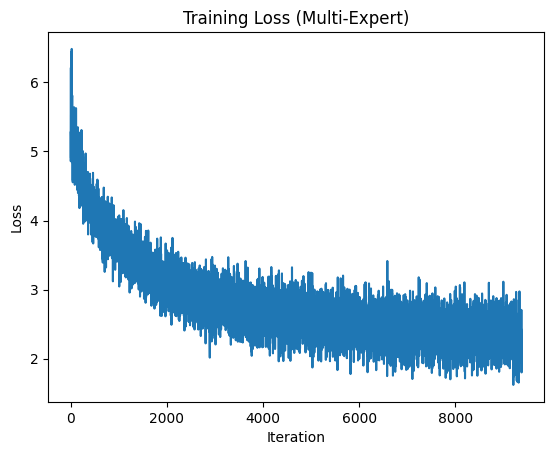

Evaluation WITH Deferral
Classifier Accuracy (excl. deferrals): 0.9332
Expert Deferral Accuracy: 0.8215
Deferral Rate: 0.3484
Overall Accuracy: 0.8943

Overall Evaluation Metrics: {'Accuracy (excluding deferrals)': 0.9332412523020258, 'Deferral Accuracy': 0.8214695752009185, 'Deferral Rate': 0.3484, 'Overall Accuracy': 0.8943}
Class 0: Classifier Acc: 0.9841, Expert Acc: 0.0000, Deferral Rate: 0.0367
Class 1: Classifier Acc: 0.9640, Expert Acc: 0.9637, Deferral Rate: 0.4370
Class 2: Classifier Acc: 0.9046, Expert Acc: 0.0000, Deferral Rate: 0.1066
Class 3: Classifier Acc: 0.9104, Expert Acc: 0.9623, Deferral Rate: 0.6574
Class 4: Classifier Acc: 0.9581, Expert Acc: 0.0000, Deferral Rate: 0.1253
Class 5: Classifier Acc: 0.8011, Expert Acc: 0.9813, Deferral Rate: 0.5998
Class 6: Classifier Acc: 0.9505, Expert Acc: 0.0000, Deferral Rate: 0.0292
Class 7: Classifier Acc: 0.9360, Expert Acc: 0.9920, Deferral Rate: 0.6051
Class 8: Classifier Acc: 0.9536, Expert Acc: 0.0000, Deferral Rate: 0.2

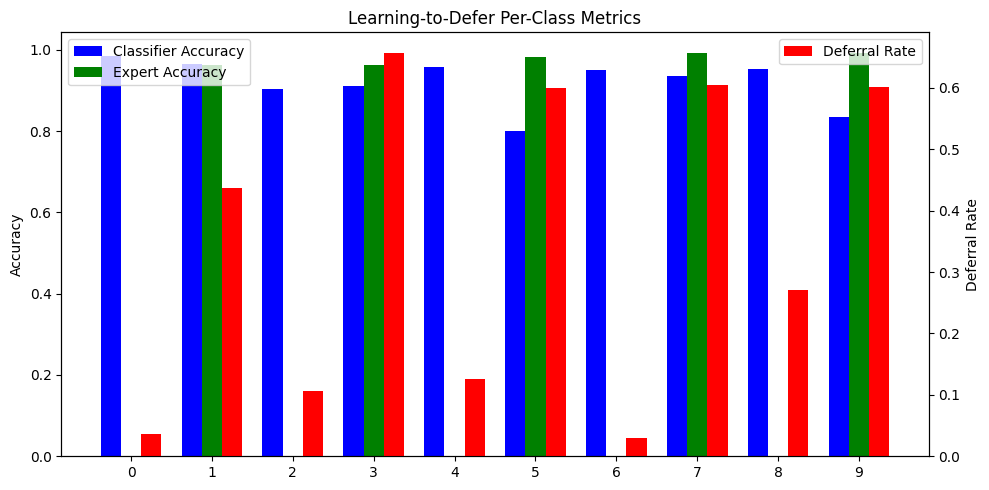

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from model_multi import LogisticRegressionMultiExpert
from data import get_dataloaders, ExpertMNIST
from l2d_functionality.l2d_loss_multi import L2D_MultiExpertLoss
from l2d_functionality.IP_l2d_inference import L2DInference
from l2d_functionality.IP_l2d_eval_combined import L2D_Eval_Combined 

# MNIST setup
input_dim = 28 * 28
num_classes = 10
num_epochs = 10
learning_rate = 1e-5
l2_lambda = 0.0 
batch_size = 64

expert_probs = [0.99, 0.9]
num_experts = len(expert_probs)

output_dim = num_classes + num_experts
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda t: torch.flatten(t))
])

train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Generate expert labels for each expert
expert_labels_train = []
expert_labels_test = []
for prob in expert_probs:
    expert = ExpertMNIST(prob)
    expert_labels_train.append(torch.tensor([expert.expert_prediction(lbl) for _, lbl in train_raw]))
    expert_labels_test.append(torch.tensor([expert.expert_prediction(lbl) for _, lbl in test_raw]))

expert_labels_train = torch.stack(expert_labels_train, dim=1)
expert_labels_test  = torch.stack(expert_labels_test, dim=1)

train_loader, test_loader = get_dataloaders(train_raw, expert_labels_train,
                                            test_raw, expert_labels_test,
                                            batch_size=batch_size)
model = LogisticRegressionMultiExpert(input_dim, num_classes, num_experts, l2_lambda)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
losses = []

l2d = L2D_MultiExpertLoss(num_classes, num_experts)

for epoch in range(num_epochs):
    for images, labels, expert_labels_batch in train_loader:
        outputs = model(images)

        loss = l2d.loss_fn(outputs, labels, expert_labels_batch, param_type="softmax")
        loss += model.l2_regularization()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print(f"Epoch {epoch+1}/{num_epochs}, Loss={np.mean(losses[-len(train_loader):]):.4f}")

# Plot training curve
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss (Multi-Expert)")
plt.savefig("training_loss_multi.png")
plt.show()

# Evaluate the model on the test set
inference = L2DInference(num_classes=num_classes, model=model)
all_preds, all_raw_preds, all_defer_idx, all_labels, all_expert_labels = inference.run(test_loader)

print("Evaluation WITH Deferral")
l2d_eval = L2D_Eval_Combined(
    num_classes,
    true_labels=all_labels,
    predicted_labels=all_preds,
    defer_idx=all_defer_idx
)
print("\nOverall Evaluation Metrics:", l2d_eval.model_report())
print("\nPer-Class Evaluation Metrics:", l2d_eval.per_class_report())
print("\nPer-Expert Metrics:", l2d_eval.expert_report())


print("\nEvaluation WITHOUT Deferral")
no_defer_idx = torch.zeros_like(all_defer_idx)
l2d_eval_no_deferral = L2D_Eval_Combined(
    num_classes,
    true_labels=all_labels,
    predicted_labels=all_raw_preds,
    defer_idx=no_defer_idx
)
print("\nOverall Evaluation Metrics:", l2d_eval_no_deferral.model_report())
print("\nPer-Class Evaluation Metrics:", l2d_eval_no_deferral.per_class_report())

l2d_eval.visualize_metrics("with_deferral_metrics.png")

# Learning from Population


=== Overlap 0.001 ===


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 31.14it/s]


Classifier Accuracy (excl. deferrals): 0.9825
Expert Deferral Accuracy: 0.4000
Deferral Rate: 0.0010
Overall Accuracy: 0.9819


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 32.33it/s]


Classifier Accuracy (excl. deferrals): 0.9864
Expert Deferral Accuracy: 0.1250
Deferral Rate: 0.0032
Overall Accuracy: 0.9836


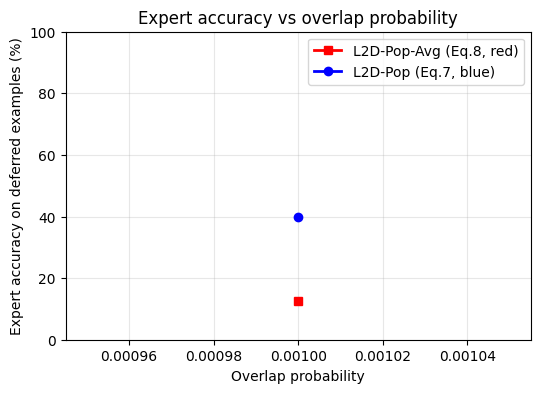

BLUE (Eq.7): [40.0]
RED (Eq.8): [12.5]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg

from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss

from l2d_functionality.IP_l2d_inference import L2DInference
from l2d_functionality.IP_l2d_eval_combined import L2D_Eval_Combined 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters & setup
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 5
lr = 1e-4
seed = 10
oracle_classes = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# overlap probabilities
overlaps = [0.001]
expert_accs = []

acc_blue, acc_popavg = [], []

for overlap in overlaps:
    print(f"\n=== Overlap {overlap} ===")
    expert_pop = PopulationSimulator(
        num_experts=num_experts,
        num_classes=num_classes,
        overlap_prob=overlap,
        oracle_classes_per_expert=oracle_classes
    )

    # Train BLUE (Eq.7)
    cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
    l2d_blue = ExpertDecisionModule(
        feature_dim=feature_dim,
        num_classes=num_classes,
        phi_dim=num_classes,
        num_experts=num_experts,
        classifier_hidden=[256],
        rejector_hidden=[128]
    ).to(device)

    loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
    optimizer_blue = optim.Adam(
        list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
        lr=lr, weight_decay=1e-4
    )
    psi = expert_pop.sample_expert_probabilities().to(device)

    for epoch in range(epochs):
        cnn_blue.train(); l2d_blue.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
            f_x = cnn_blue(imgs)
            g_classes, g_perp = l2d_blue(f_x, psi)
            loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)
            optimizer_blue.zero_grad()
            loss.backward()
            optimizer_blue.step()

    # Run BLUE inference & evaluation
    inference_blue = L2DInference(num_classes, cnn=cnn_blue, l2d=l2d_blue,
                                 expert_pop=expert_pop, device=device, expert_aware=True)
    final_preds, raw_preds, defer_idx, labels, expert_labels = inference_blue._run_population(test_loader, expert_idx=0)
    evaluator_blue = L2D_Eval_Combined(num_classes, labels, final_preds, defer_idx)
    blue_report = evaluator_blue.model_report()
    acc_blue.append(blue_report['Deferral Accuracy'] * 100)

    # Train RED (Eq.8)
    model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
    loss_red = L2D_PopAvg_Loss(num_classes)
    optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        model_red.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
            g_classes, g_perp = model_red(imgs)
            loss = loss_red(g_classes, g_perp, labels, expert_preds)
            optimizer_red.zero_grad()
            loss.backward()
            optimizer_red.step()

    # Run RED inference & evaluation
    inference_red = L2DInference(num_classes, cnn=None, l2d=model_red,
                                expert_pop=expert_pop, device=device, expert_aware=False)
    final_preds_red, raw_preds_red, defer_idx_red, labels_red, expert_labels_red = inference_red._run_population(test_loader, expert_idx=0)
    evaluator_red = L2D_Eval_Combined(num_classes, labels_red, final_preds_red, defer_idx_red)
    red_report = evaluator_red.model_report()
    acc_popavg.append(red_report['Deferral Accuracy'] * 100)



plt.figure(figsize=(6,4))
plt.plot(overlaps, acc_popavg, 's-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.plot(overlaps, acc_blue, 'o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability")
plt.show()

print("BLUE (Eq.7):", acc_blue)
print("RED (Eq.8):", acc_popavg)



Seed 10

Overlap 0.005


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 22.52it/s]


Classifier Accuracy (excl. deferrals): 0.9828
Expert Deferral Accuracy: 0.3200
Deferral Rate: 0.0025
Overall Accuracy: 0.9811


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 28.78it/s]


Classifier Accuracy (excl. deferrals): 0.9869
Expert Deferral Accuracy: 0.1538
Deferral Rate: 0.0039
Overall Accuracy: 0.9837

Overlap 0.01


...

Classifier Accuracy (excl. deferrals): 0.9959
Expert Deferral Accuracy: 0.3425
Deferral Rate: 0.0581
Overall Accuracy: 0.9579

Overlap 0.5


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 30.51it/s]


Classifier Accuracy (excl. deferrals): 0.9971
Expert Deferral Accuracy: 0.5384
Deferral Rate: 0.0782
Overall Accuracy: 0.9612


Eval (expert 0): 100%|██████████| 20/20 [00:00<00:00, 29.51it/s]

Classifier Accuracy (excl. deferrals): 0.9977
Expert Deferral Accuracy: 0.5624
Deferral Rate: 0.0761
Overall Accuracy: 0.9646


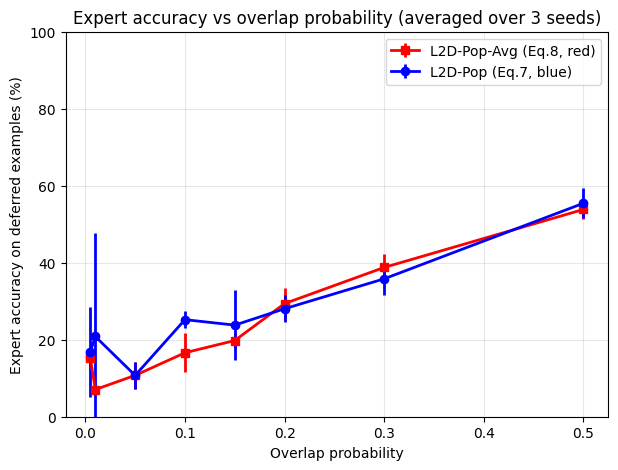

BLUE (Eq.7) mean: [16.83950617 20.84241104 10.72658279 25.21521945 23.79192298 28.04982978
 35.82505935 55.44949003]
RED (Eq.8) mean: [15.27777778  7.05582137 10.73525106 16.61679823 19.7912187  29.38994953
 38.78196182 53.83978652]
BLUE (Eq.7) std err: [11.64029288 26.8992363   3.56225353  2.27010299  9.04357457  3.53880202
  4.07975766  3.86080179]
RED (Eq.8) std err: [2.22571225 0.78858229 3.42187194 5.06424165 1.85396991 4.14922259
 3.59891981 2.50267304]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import sys
import os
sys.path.append(os.path.abspath('..'))

from learning_from_population_utils.data_from_population import PopulationSimulator
from learning_from_population_utils.model_from_population import SimpleCNNFeatureExtractor, ExpertDecisionModule, ExpertDecisionModuleAvg
from l2d_functionality.l2d_loss_from_pop import L2D_Equation7_Loss, L2D_PopAvg_Loss
from l2d_functionality.IP_l2d_inference import L2DInference
from l2d_functionality.IP_l2d_eval_combined import L2D_Eval_Combined 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def make_tensors(dataset_raw):
    imgs, labels = [], []
    for img, label in dataset_raw:
        imgs.append(img)
        labels.append(int(label))
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_tensors(train_raw)
test_images, test_labels   = make_tensors(test_raw)

batch_size = 256
train_loader = DataLoader(TensorDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_images, test_labels), batch_size=512, shuffle=False)

# Hyperparameters
num_classes = 10
num_experts = 10
phi_dim = 8
feature_dim = 128
epochs = 5
lr = 1e-4
oracle_classes = 1

overlaps = [0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
seeds = [10, 20, 30]   # Run three different seeds

# To store results across seeds
all_acc_blue = []
all_acc_red = []

for seed in seeds:
    print(f"\nSeed {seed}")
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    acc_blue = []
    acc_popavg = []

    for overlap in overlaps:
        print(f"\nOverlap {overlap}")
        expert_pop = PopulationSimulator(
            num_experts=num_experts,
            num_classes=num_classes,
            overlap_prob=overlap,
            oracle_classes_per_expert=oracle_classes
        )

        # ---------------- BLUE (Eq.7) ----------------
        cnn_blue = SimpleCNNFeatureExtractor(out_dim=feature_dim).to(device)
        l2d_blue = ExpertDecisionModule(
            feature_dim=feature_dim,
            num_classes=num_classes,
            phi_dim=num_classes,
            num_experts=num_experts,
            classifier_hidden=[256],
            rejector_hidden=[128]
        ).to(device)

        loss_eq7 = L2D_Equation7_Loss(num_classes, num_experts)
        optimizer_blue = optim.Adam(
            list(cnn_blue.parameters()) + list(l2d_blue.parameters()),
            lr=lr, weight_decay=1e-4
        )
        psi = expert_pop.sample_expert_probabilities().to(device)

        for epoch in range(epochs):
            cnn_blue.train(); l2d_blue.train()
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
                f_x = cnn_blue(imgs)
                g_classes, g_perp = l2d_blue(f_x, psi)
                loss = loss_eq7.forward(g_classes, g_perp, labels, expert_preds)
                optimizer_blue.zero_grad()
                loss.backward()
                optimizer_blue.step()

        inference_blue = L2DInference(num_classes, cnn=cnn_blue, l2d=l2d_blue,
                                     expert_pop=expert_pop, device=device, expert_aware=True)
        final_preds, _, defer_idx, labels, _ = inference_blue._run_population(test_loader, expert_idx=0)
        evaluator_blue = L2D_Eval_Combined(num_classes, labels, final_preds, defer_idx)
        blue_report = evaluator_blue.model_report()
        acc_blue.append(blue_report['Deferral Accuracy'] * 100)

        # ---------------- RED (Eq.8) ----------------
        model_red = ExpertDecisionModuleAvg(feature_dim=feature_dim, num_classes=num_classes).to(device)
        loss_red = L2D_PopAvg_Loss(num_classes)
        optimizer_red = optim.Adam(model_red.parameters(), lr=lr, weight_decay=1e-4)

        for epoch in range(epochs):
            model_red.train()
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                expert_preds = expert_pop.sample_predictions_given_phi(labels.cpu(), psi.cpu()).to(device)
                g_classes, g_perp = model_red(imgs)
                loss = loss_red(g_classes, g_perp, labels, expert_preds)
                optimizer_red.zero_grad()
                loss.backward()
                optimizer_red.step()

        inference_red = L2DInference(num_classes, cnn=None, l2d=model_red,
                                    expert_pop=expert_pop, device=device, expert_aware=False)
        final_preds_red, _, defer_idx_red, labels_red, _ = inference_red._run_population(test_loader, expert_idx=0)
        evaluator_red = L2D_Eval_Combined(num_classes, labels_red, final_preds_red, defer_idx_red)
        red_report = evaluator_red.model_report()
        acc_popavg.append(red_report['Deferral Accuracy'] * 100)

    all_acc_blue.append(acc_blue)
    all_acc_red.append(acc_popavg)

all_acc_blue = np.array(all_acc_blue)
all_acc_red = np.array(all_acc_red)

mean_blue = np.mean(all_acc_blue, axis=0)
std_blue  = np.std(all_acc_blue, axis=0)
mean_red  = np.mean(all_acc_red, axis=0)
std_red   = np.std(all_acc_red, axis=0)

# Plot results
plt.figure(figsize=(7,5))
plt.errorbar(overlaps, mean_red, yerr=std_red, fmt='s-', color='r', lw=2, label='L2D-Pop-Avg (Eq.8, red)')
plt.errorbar(overlaps, mean_blue, yerr=std_blue, fmt='o-', color='b', lw=2, label='L2D-Pop (Eq.7, blue)')
plt.xlabel("Overlap probability")
plt.ylabel("Expert accuracy on deferred examples (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Expert accuracy vs overlap probability (averaged over 3 seeds)")
plt.show()

print("BLUE (Eq.7) mean:", mean_blue)
print("RED (Eq.8) mean:", mean_red)
print("BLUE (Eq.7) std err:", std_blue)
print("RED (Eq.8) std err:", std_red)
